# Chapter 0 -- Python tutorial

A short standalone tour of core NumPy and Matplotlib: array creation and
indexing, string handling, 2D/3D plotting, Monte Carlo convergence,
struct-like records, N-D array manipulation (stacking, reshape, permute,
eigendecomposition), single vs. double precision, linear regression and
polynomial curve fitting, grouped accumulation, and functions with
multiple return values. Just NumPy and Matplotlib, nothing else.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)  # fixed seed for reproducibility
%matplotlib inline


## 0. Figure basics

A blank figure.

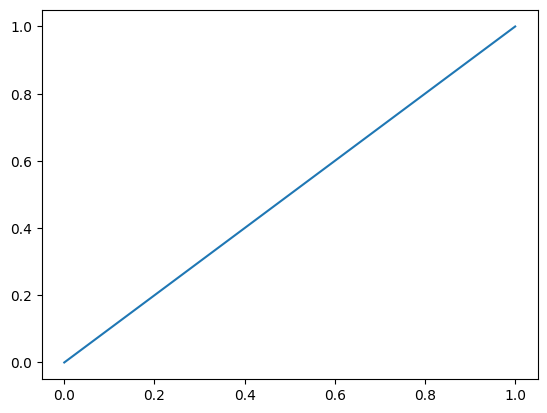

In [2]:
fig, ax = plt.subplots()
ax.plot([0, 1], [0, 1])
fig.patch.set_facecolor("white")
plt.show()

## 1. Arrays and indexing

Random arrays via `rng.random`/`rng.standard_normal`; elementwise
multiplication with `*`; and strided slicing, e.g. `np.arange(0, 5, 2)`
for every other index.

In [3]:
n = 5
a = rng.random((n, n))
b = rng.standard_normal((n, n))
c = a * b
np.set_printoptions(precision=4, suppress=True)
print(c)

[[ 0.0599 -0.2006 -0.0378 -0.0076  0.1791]
 [-0.9215 -0.1269 -0.1162  0.294   0.2007]
 [ 0.2899 -0.0018 -0.1111  0.0263  1.0897]
 [-0.2212  1.3068  0.7287  0.2342  0.1118]
 [-0.0089  0.1812  1.3146  1.166   0.8093]]


In [4]:
c[0:2, 0:2]

array([[ 0.0599, -0.2006],
       [-0.9215, -0.1269]])

In [5]:
c[:, 0:2]

array([[ 0.0599, -0.2006],
       [-0.9215, -0.1269],
       [ 0.2899, -0.0018],
       [-0.2212,  1.3068],
       [-0.0089,  0.1812]])

In [6]:
idx = np.arange(0, 5, 2)  # every other index, 0..4
print(idx)
d = c[idx, :]
d

[0 2 4]


array([[ 0.0599, -0.2006, -0.0378, -0.0076,  0.1791],
       [ 0.2899, -0.0018, -0.1111,  0.0263,  1.0897],
       [-0.0089,  0.1812,  1.3146,  1.166 ,  0.8093]])

In [7]:
def magic(n):
    """Magic square, n odd (Siamese method)."""
    m = np.zeros((n, n), dtype=int)
    i, j = 0, n // 2
    for k in range(1, n * n + 1):
        m[i, j] = k
        ni, nj = (i - 1) % n, (j + 1) % n
        if m[ni, nj]:
            ni, nj = (i + 1) % n, j
        i, j = ni, nj
    return m

A = magic(n)
A

array([[17, 24,  1,  8, 15],
       [23,  5,  7, 14, 16],
       [ 4,  6, 13, 20, 22],
       [10, 12, 19, 21,  3],
       [11, 18, 25,  2,  9]])

## 2. Strings and display

Basic string handling, then array summary stats: `.dtype`/`.shape`/
`.nbytes` for a variable's layout, `np.maximum` for an elementwise max,
and `.max()`/`.argmax()` for the max value and its location together.

In [8]:
text1 = "hello, world"
text2 = 'hello" world'
text3 = 'hello world"'
print(text1)
print(text2)
print(text3)

a = rng.random((5, 5))
print("a:", a.dtype, a.shape, a.nbytes, "bytes")
print("text1:", type(text1).__name__, len(text1), "chars")

newtext = text1 + " " + text2
newtext

hello, world
hello" world
hello world"
a: float64 (5, 5) 200 bytes
text1: str 12 chars


'hello, world hello" world'

In [9]:
print(np.array2string(a))

A = rng.random(5)
print(A.max())

A = rng.standard_normal((5, 5))
B = np.ones((5, 5))
print(A)
np.maximum(np.abs(A), B)

[[0.7871 0.2394 0.8765 0.0586 0.3361]
 [0.1503 0.4503 0.7963 0.2306 0.052 ]
 [0.4046 0.1985 0.0908 0.5803 0.2987]
 [0.672  0.1995 0.9421 0.3651 0.1055]
 [0.6291 0.9272 0.4404 0.9546 0.4999]]
0.9950965052353241
[[ 0.0491  2.0024  0.1885 -0.6332 -0.3776]
 [-1.0911 -1.2777  0.6304  0.5812  1.2946]
 [-0.7546  1.6891 -0.2874  1.5744 -0.4328]
 [-0.7355  0.2498  1.0315  0.161  -0.5855]
 [-1.3412 -1.4015  0.5027  0.9897 -0.1643]]


array([[1.    , 2.0024, 1.    , 1.    , 1.    ],
       [1.0911, 1.2777, 1.    , 1.    , 1.2946],
       [1.    , 1.6891, 1.    , 1.5744, 1.    ],
       [1.    , 1.    , 1.0315, 1.    , 1.    ],
       [1.3412, 1.4015, 1.    , 1.    , 1.    ]])

In [10]:
max_A = np.abs(A).max()
location_max = np.abs(A).argmax()
max_A, location_max

(np.float64(2.002392583645255), np.int64(1))

## 3. Plotting: 2D lines, surfaces, subplots

Line plots, a 3D surface via `np.meshgrid`/`Axes3D.plot_surface`, and a
2x2 grid of subplots.

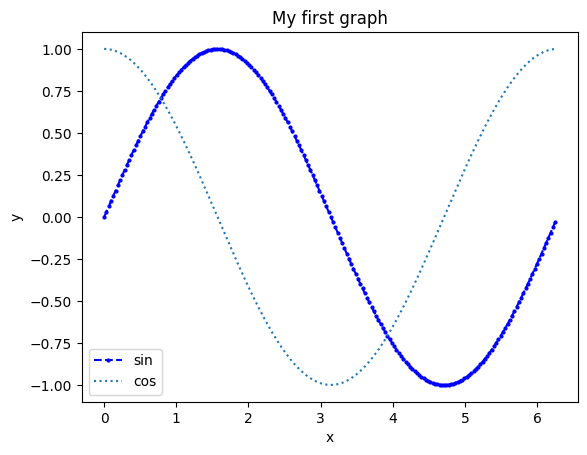

In [11]:
x = np.arange(0, 2 * np.pi, np.pi / 100)
y = np.sin(x)
y2 = np.cos(x)

fig, ax = plt.subplots()
ax.plot(x, y, "b--o", markersize=2, label="sin")
ax.plot(x, y2, ":", label="cos")
ax.set_title("My first graph")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.show()

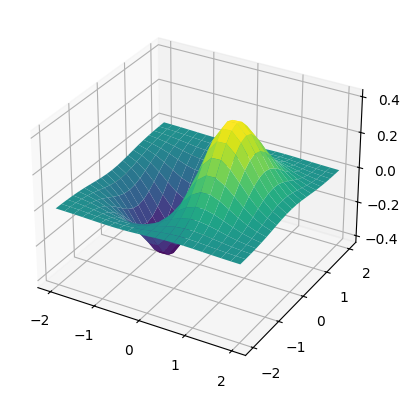

In [12]:
xx, yy = np.meshgrid(np.arange(-2, 2.01, 0.2), np.arange(-2, 2.01, 0.2))
zz = xx * np.exp(-(xx**2) - yy**2)

fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.plot_surface(xx, yy, zz, cmap="viridis")
plt.show()

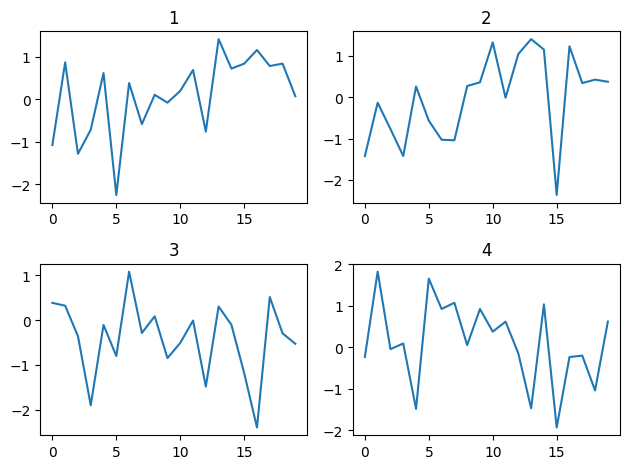

In [13]:
fig, axes = plt.subplots(2, 2)
for k, ax in enumerate(axes.flat, start=1):
    ax.plot(rng.standard_normal(20))
    ax.set_title(str(k))
fig.tight_layout()
plt.show()

## 4. Monte Carlo mean convergence

Uniform samples on [0, 1]; running mean should converge to 0.5.

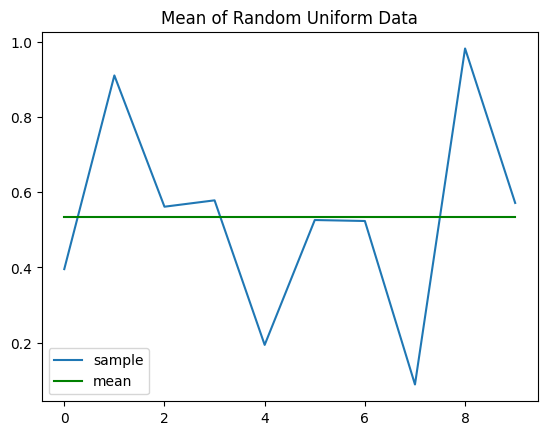

final running mean: 0.5010 (ok)
iterations flagged 'below'/'above': 14 / 500


In [14]:
n = 10
r = rng.random(n)

fig, ax = plt.subplots()
ax.plot(r, label="sample")
m = r.mean()
ax.plot([0, n - 1], [m, m], "g", label="mean")
ax.set_title("Mean of Random Uniform Data")
ax.legend()
plt.show()

n_s = 500
n_x = 50
sum_x = 0.0
m_x = np.zeros(n_s)
for i in range(1, n_s + 1):
    x = rng.random(n_x)
    sum_x += x.mean()
    m_x[i - 1] = sum_x / i

status = np.where(m_x < 0.49, "below", np.where(m_x > 0.51, "above", "ok"))
print(f"final running mean: {m_x[-1]:.4f} ({status[-1]})")
print(f"iterations flagged 'below'/'above': {(status != 'ok').sum()} / {n_s}")

## 5. Struct arrays

A small list of per-record dicts, each holding scalar fields alongside
an array field -- a lightweight stand-in for a record/struct array.

In [15]:
patients = [
    {"name": "John Doe", "billing": 127.00,
     "test": np.array([[79, 75, 73], [180, 178, 177.5], [220, 210, 205]]), "x": 1},
    {"name": "Me", "billing": 17.00,
     "test": np.array([[-79, -75, 73], [180, 178, 177.5], [220, 210, 205]]), "x": 2},
    {"name": "Other", "billing": 17.00,
     "test": np.array([[79, 5, 3], [18, 17, 17], [22, 21, 205]]), "x": 3},
]
patients[0]

{'name': 'John Doe',
 'billing': 127.0,
 'test': array([[ 79. ,  75. ,  73. ],
        [180. , 178. , 177.5],
        [220. , 210. , 205. ]]),
 'x': 1}

In [16]:
patients[2]

{'name': 'Other',
 'billing': 17.0,
 'test': array([[ 79,   5,   3],
        [ 18,  17,  17],
        [ 22,  21, 205]]),
 'x': 3}

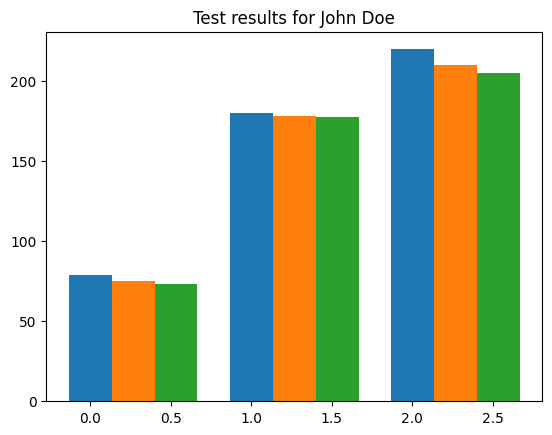

127.0

In [17]:
amount_due = patients[0]["billing"]

fig, ax = plt.subplots()
test = patients[0]["test"]
x_pos = np.arange(test.shape[0])
width = 0.8 / test.shape[1]
for j in range(test.shape[1]):
    ax.bar(x_pos + j * width, test[:, j], width)
ax.set_title(f"Test results for {patients[0]['name']}")
plt.show()

amount_due

## 6. N-D arrays: stacking, reshape, permute, eig, ndgrid

Stacking 2D arrays along a new axis with `np.stack(..., axis=2)`, then
reshaping, permuting axes, squeezing singleton dimensions, and taking an
eigendecomposition.

In [18]:
r, c, n = 5, 10, 100
a = np.stack([rng.random((r, c)) for _ in range(n)], axis=2)
b = np.stack([a, a**2, -a], axis=3)

a[:, :, n - 1]

array([[0.4071, 0.9115, 0.8315, 0.1515, 0.8862, 0.0157, 0.3209, 0.6565,
        0.0998, 0.9263],
       [0.8029, 0.0278, 0.5312, 0.2356, 0.2629, 0.0444, 0.4394, 0.1311,
        0.611 , 0.0799],
       [0.8733, 0.9919, 0.5873, 0.5439, 0.1932, 0.5612, 0.4462, 0.439 ,
        0.0499, 0.4   ],
       [0.8152, 0.5556, 0.7889, 0.1749, 0.713 , 0.5658, 0.3548, 0.9283,
        0.4259, 0.6211],
       [0.136 , 0.1869, 0.6398, 0.7844, 0.0743, 0.8136, 0.0711, 0.2829,
        0.0661, 0.854 ]])

In [19]:
b[:, :, n - 1, 2]

array([[-0.4071, -0.9115, -0.8315, -0.1515, -0.8862, -0.0157, -0.3209,
        -0.6565, -0.0998, -0.9263],
       [-0.8029, -0.0278, -0.5312, -0.2356, -0.2629, -0.0444, -0.4394,
        -0.1311, -0.611 , -0.0799],
       [-0.8733, -0.9919, -0.5873, -0.5439, -0.1932, -0.5612, -0.4462,
        -0.439 , -0.0499, -0.4   ],
       [-0.8152, -0.5556, -0.7889, -0.1749, -0.713 , -0.5658, -0.3548,
        -0.9283, -0.4259, -0.6211],
       [-0.136 , -0.1869, -0.6398, -0.7844, -0.0743, -0.8136, -0.0711,
        -0.2829, -0.0661, -0.854 ]])

In [20]:
b.shape

(5, 10, 100, 3)

In [21]:
b.ndim

4

In [22]:
b[0, 0, 2, :]

array([ 0.627 ,  0.3932, -0.627 ])

In [23]:
x = np.arange(1, 101)
a = x[0:24].reshape(4, 3, 2, order="F")  # column-major reshape
a

array([[[ 1, 13],
        [ 5, 17],
        [ 9, 21]],

       [[ 2, 14],
        [ 6, 18],
        [10, 22]],

       [[ 3, 15],
        [ 7, 19],
        [11, 23]],

       [[ 4, 16],
        [ 8, 20],
        [12, 24]]])

In [24]:
np.transpose(a, (0, 2, 1))

array([[[ 1,  5,  9],
        [13, 17, 21]],

       [[ 2,  6, 10],
        [14, 18, 22]],

       [[ 3,  7, 11],
        [15, 19, 23]],

       [[ 4,  8, 12],
        [16, 20, 24]]])

In [25]:
b6 = a[0:1, :, :]
a = x[0:12].reshape(4, 3, order="F")
a

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

In [26]:
b6 = np.squeeze(b6)
b6

array([[ 1, 13],
       [ 5, 17],
       [ 9, 21]])

In [27]:
a = a[0:3, 0:3]
eigvals, eigvecs = np.linalg.eig(a)
eigvals, eigvecs

(array([19.247, -1.247, -0.   ]),
 array([[ 0.4835,  0.8921,  0.4082],
        [ 0.5727,  0.2619, -0.8165],
        [ 0.662 , -0.3682,  0.4082]]))

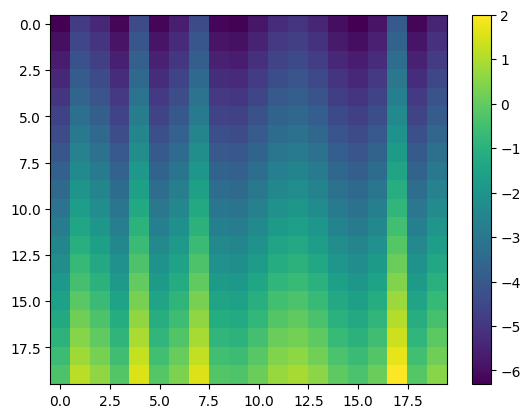

In [28]:
x1 = np.arange(-2 * np.pi, 0, np.pi / 10)
x2 = np.arange(2 * np.pi, 4 * np.pi, np.pi / 10)
x3 = np.arange(0, 2 * np.pi, np.pi / 10)
X1, X2, X3 = np.meshgrid(x1, x2, x3, indexing="ij")
z = X1 + np.exp(np.cos(2 * X2**2)) + np.sin(X3**3)

# A 2D slice through the volume at its midpoint
fig, ax = plt.subplots()
im = ax.imshow(z[:, :, z.shape[2] // 2], aspect="auto")
fig.colorbar(im)
plt.show()

## 7. Single vs. double precision

`np.float32` vs. the default double precision, and how that affects a
matrix inversion.

In [29]:
A = np.array([[1, 2, 0], [2, 5, -1], [4, 10, -1]], dtype=float)
print("A =\n", A)
B_single = A.astype(np.float32)
print("B (single) =\n", B_single)

A =
 [[ 1.  2.  0.]
 [ 2.  5. -1.]
 [ 4. 10. -1.]]
B (single) =
 [[ 1.  2.  0.]
 [ 2.  5. -1.]
 [ 4. 10. -1.]]


In [30]:
B = rng.random((5, 5))
C = rng.random((5, 5))
A = B * C
D = np.linalg.inv(A)
print(A)

A32 = B.astype(np.float32) * C.astype(np.float32)
print(A32)
np.set_printoptions(precision=8, suppress=False)
print(A @ D)
print(A @ np.linalg.inv(A))
np.set_printoptions(precision=4, suppress=True)

[[0.0403 0.2023 0.7847 0.0969 0.1334]
 [0.1214 0.2107 0.3756 0.1371 0.7422]
 [0.5465 0.1484 0.0236 0.1087 0.1971]
 [0.9165 0.8622 0.0298 0.042  0.0152]
 [0.0936 0.0193 0.0137 0.4037 0.4308]]
[[0.0403 0.2023 0.7847 0.0969 0.1334]
 [0.1214 0.2107 0.3756 0.1371 0.7422]
 [0.5465 0.1484 0.0236 0.1087 0.1971]
 [0.9165 0.8622 0.0298 0.042  0.0152]
 [0.0936 0.0193 0.0137 0.4037 0.4308]]
[[ 1.00000000e+00 -1.13160205e-17  4.37873876e-18  3.49605372e-17
   3.72812981e-18]
 [ 6.31348681e-17  1.00000000e+00 -3.66104352e-17 -1.62928591e-17
  -4.03041128e-17]
 [-2.32928918e-17  3.73321692e-17  1.00000000e+00 -1.94318966e-16
  -3.21472372e-17]
 [ 3.60338251e-18  6.66186363e-17 -1.20900616e-16  1.00000000e+00
  -4.62740925e-17]
 [-2.84698992e-17  5.06306434e-17  6.46576785e-18 -1.19686959e-18
   1.00000000e+00]]
[[ 1.00000000e+00 -1.13160205e-17  4.37873876e-18  3.49605372e-17
   3.72812981e-18]
 [ 6.31348681e-17  1.00000000e+00 -3.66104352e-17 -1.62928591e-17
  -4.03041128e-17]
 [-2.32928918e-17  3.7

## 8. Linear regression and polynomial curve fitting

US population 1900-2000, decade steps -- a straight-line OLS fit
(`inv(x'x)x'y`), then a degree-3 polynomial fit through a rescaled time
variable (`s = (t-1950)/50`), extrapolated to 2010.

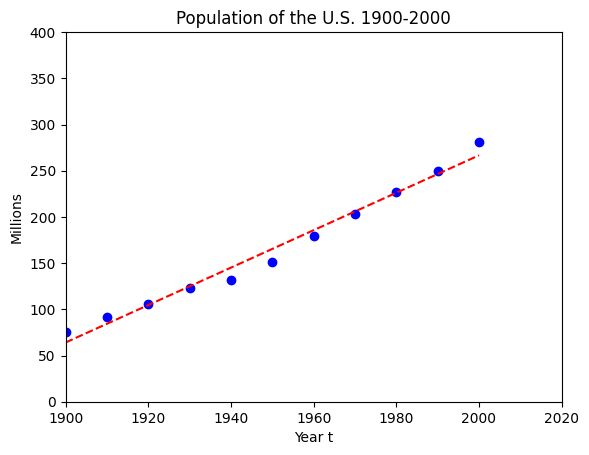

array([-3783.9456,     2.0253])

In [31]:
t = np.arange(1900, 2001, 10, dtype=float)
p = np.array([75.995, 91.972, 105.711, 123.203, 131.669,
              150.697, 179.323, 203.212, 226.505, 249.633, 281.422])

fig, ax = plt.subplots()
ax.plot(t, p, "bo")
ax.set_xlim(1900, 2020)
ax.set_ylim(0, 400)
ax.set_title("Population of the U.S. 1900-2000")
ax.set_ylabel("Millions")
ax.set_xlabel("Year t")

x = np.column_stack([np.ones_like(t), t])
y = p
beta = np.linalg.inv(x.T @ x) @ x.T @ y
y_hat = x @ beta

ax.plot(t, y_hat, "r--")
plt.show()
beta

In [32]:
n = len(t)
s = (t - 1950) / 50
degree = 3
c = np.polyfit(s, p, degree)
c

array([  1.2629,  23.7261, 100.3659, 155.9043])

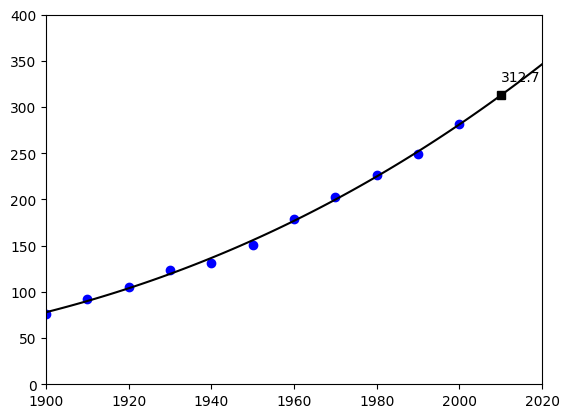

np.float64(312.6913787878789)

In [33]:
v = np.arange(1900, 2021)
x_scaled = (v - 1950) / 50
w = (2010 - 1950) / 50
y_poly = np.polyval(c, x_scaled)
z = np.polyval(c, w)

fig, ax = plt.subplots()
ax.plot(t, p, "bo")
ax.plot(v, y_poly, "k-")
ax.plot(2010, z, "ks")
ax.annotate(f"{z:.1f}", (2010, z + 15))
ax.set_xlim(1900, 2020)
ax.set_ylim(0, 400)
plt.show()
z

## 9. Grouped accumulation

Summing values into bins by index with `np.bincount(subs, weights=...)`.

In [34]:
A = np.array([1, 2, 3, 4, 2, 4, 5, 10])
b1 = np.bincount(A)[1:]  # drop bin 0, values start at 1
b2 = np.bincount(A, weights=np.full(A.shape, 2))[1:]
A, np.column_stack([b1, b2, b1 * 2])

(array([ 1,  2,  3,  4,  2,  4,  5, 10]),
 array([[1., 2., 2.],
        [2., 4., 4.],
        [1., 2., 2.],
        [2., 4., 4.],
        [1., 2., 2.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [1., 2., 2.]]))

## 10. Functions with multiple return values

A plain tuple return -- no special syntax needed.

In [35]:
def ma_fonction(x, y):
    fx = np.exp(x)
    fy = np.cos(y)
    return fx, fy

a, b = ma_fonction(1, 0)
print(a, b)

a, b = ma_fonction(np.array([1, 0, 3]), np.array([0, 5]))
print(a)
print(b)

2.718281828459045 1.0
[ 2.7183  1.     20.0855]
[1.     0.2837]
